In [1]:
! pip install nltk

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)


## load packages

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk import pos_tag

pd.set_option('display.max_columns', None)

In [3]:
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt_tab')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/jovyan/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt_tab to /home/jovyan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
import os

print(os.getcwd())

/home/jovyan/sp25-student/grad-proj/nlp-chatbot-analysis


In [5]:
import warnings
warnings.filterwarnings('ignore')

## load data

In [6]:
dat = pd.read_csv('complete_data_for_tasks_deciphered.csv')

print(dat.shape)
dat.head(5)

(25256, 16)


,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner
0,What is the difference between OpenCL and CUDA?,Technical Comparison,This prompt requires the AI to accurately comp...,9,Software Comparison,This prompt assesses the AI's factual accuracy...,8,"Comparison, Technology",This prompt requires the AI to demonstrate kno...,9,"Comparison, Time","Technology, Engineering","Comparison, Time",chatglm-6b,koala-13b,model_b
1,Why did my parent not invite me to their wedding?,"Reasoning, Emotion",This prompt requires the AI to understand huma...,9,"Emotions, Relationships",This prompt involves understanding complex hum...,8,"Reasoning, Emotional",This prompt challenges the AI to infer motives...,8,"Emotional, Psychology","Emotional, Psychology","Emotional, Psychology",oasst-pythia-12b,alpaca-13b,tie
2,"Fuji vs. Nikon, which is better?",Camera comparison,This prompt does not require problem-solving s...,2,Comparative Analysis,This prompt assesses the AI's ability to analy...,6,Photography comparison,This prompt is subjective and does not provide...,2,"Identification, Classification","Comparison, Time","Identification, Classification",koala-13b,oasst-pythia-12b,model_b
3,How to build an arena for chatbots?,Chatbot Arena,This prompt requires problem-solving skills an...,8,Chatbot Arena,This prompt requires the AI to engage in probl...,8,Chatbot Arena,This prompt requires problem-solving skills an...,8,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",vicuna-13b,oasst-pythia-12b,model_b
4,When is it today?,Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,"Comparison, Time","Comparison, Time","Comparison, Time",vicuna-13b,koala-13b,model_a


In [7]:
prompt_embeddings = np.load('prompt_embeddings.npy')

print(prompt_embeddings.shape)
prompt_embeddings

(25256, 256)


array([[-0.12376316, -0.1173524 ,  0.04567662, ..., -0.02439648,
        -0.03724024, -0.04380682],
       [ 0.00602781,  0.02843601, -0.09102212, ...,  0.08506154,
        -0.05333152,  0.00185428],
       [-0.03522179, -0.10940242, -0.02224718, ..., -0.14116742,
         0.00477351,  0.00416916],
       ...,
       [ 0.02476096, -0.02741823,  0.07049022, ..., -0.05541623,
        -0.02461602,  0.06005438],
       [ 0.01620374,  0.04473886,  0.08496623, ..., -0.02189322,
        -0.05438842,  0.02849752],
       [-0.04179214,  0.00963908, -0.00338678, ...,  0.08221702,
        -0.02381286, -0.10591594]], dtype=float32)

## feature engineering

In [8]:
temp_cols = ['score_value_1','score_value_2','score_value_3']
dat[temp_cols] = dat[temp_cols].astype(int)

In [9]:
# helper function
# count the number of punctuations ',:?.' in the prompt question

def count_punctuation(sentence):
    punctuation_counts = Counter(char for char in sentence if char in ',:?.')
    total_punctuation = sum(punctuation_counts.values())
    return total_punctuation

In [10]:
# count the number of words in the prompt question
# log transformation
dat['prompt_word_count'] = dat['prompt'].str.split().str.len()
dat['prompt_word_count_log'] = np.log(dat['prompt_word_count'])

# count the number of characters in the prompt question
# log transformation
dat['prompt_char_count'] = dat['prompt'].str.len()
dat['prompt_char_count_log'] = np.log(dat['prompt_char_count'])

# count the number of punctuations ',:?.' in the prompt question
# fix outliers by capping at 200
# fix the lower bound of value 0, ready for log transformation
# log transformation
dat['prompt_punc_count'] = dat['prompt'].apply(count_punctuation)
dat.loc[(dat['prompt_punc_count']>200), 'prompt_punc_count'] = 200
dat.loc[(dat['prompt_punc_count']==0), 'prompt_punc_count'] = 1
dat['prompt_punc_count_log'] = np.log(dat['prompt_punc_count'])

dat.head()

,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner,prompt_word_count,prompt_word_count_log,prompt_char_count,prompt_char_count_log,prompt_punc_count,prompt_punc_count_log
0,What is the difference between OpenCL and CUDA?,Technical Comparison,This prompt requires the AI to accurately comp...,9,Software Comparison,This prompt assesses the AI's factual accuracy...,8,"Comparison, Technology",This prompt requires the AI to demonstrate kno...,9,"Comparison, Time","Technology, Engineering","Comparison, Time",chatglm-6b,koala-13b,model_b,8,2.079442,47,3.850148,1,0.000000
1,Why did my parent not invite me to their wedding?,"Reasoning, Emotion",This prompt requires the AI to understand huma...,9,"Emotions, Relationships",This prompt involves understanding complex hum...,8,"Reasoning, Emotional",This prompt challenges the AI to infer motives...,8,"Emotional, Psychology","Emotional, Psychology","Emotional, Psychology",oasst-pythia-12b,alpaca-13b,tie,10,2.302585,49,3.891820,1,0.000000
2,"Fuji vs. Nikon, which is better?",Camera comparison,This prompt does not require problem-solving s...,2,Comparative Analysis,This prompt assesses the AI's ability to analy...,6,Photography comparison,This prompt is subjective and does not provide...,2,"Identification, Classification","Comparison, Time","Identification, Classification",koala-13b,oasst-pythia-12b,model_b,6,1.791759,32,3.465736,3,1.098612
3,How to build an arena for chatbots?,Chatbot Arena,This prompt requires problem-solving skills an...,8,Chatbot Arena,This prompt requires the AI to engage in probl...,8,Chatbot Arena,This prompt requires problem-solving skills an...,8,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",vicuna-13b,oasst-pythia-12b,model_b,7,1.945910,35,3.555348,1,0.000000
4,When is it today?,Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,"Comparison, Time","Comparison, Time","Comparison, Time",vicuna-13b,koala-13b,model_a,4,1.386294,17,2.833213,1,0.000000


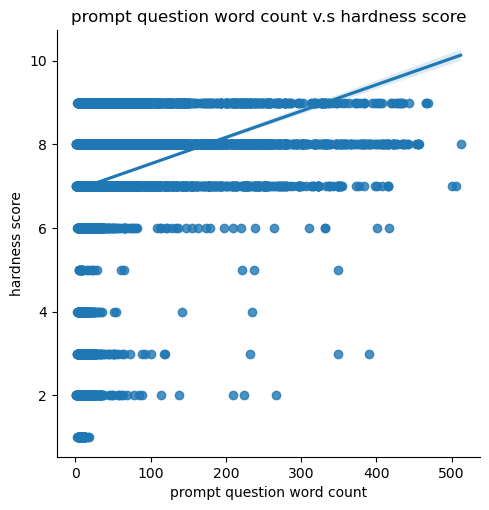

In [11]:
sns.lmplot(data=dat, x='prompt_word_count', y='score_value_1')
plt.xlabel('prompt question word count')
plt.ylabel('hardness score')
plt.title('prompt question word count v.s hardness score')
plt.show()

Text(0.5, 1.0, 'prompt question character count v.s hardness score')

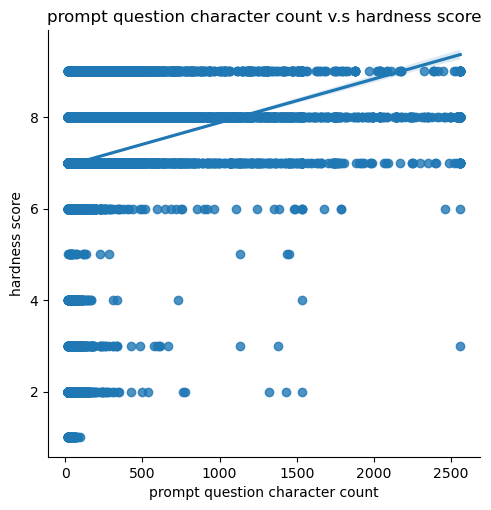

In [12]:
sns.lmplot(data=dat, x='prompt_char_count', y='score_value_1')
plt.xlabel('prompt question character count')
plt.ylabel('hardness score')
plt.title('prompt question character count v.s hardness score')

Text(0.5, 1.0, 'prompt question punctuation count v.s hardness score')

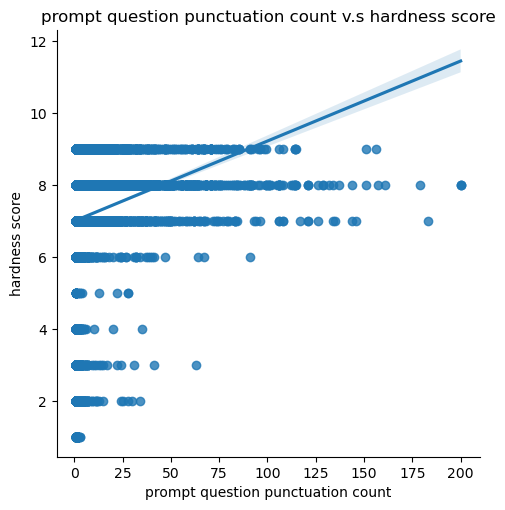

In [13]:
sns.lmplot(data=dat, x='prompt_punc_count', y='score_value_1')
plt.xlabel('prompt question punctuation count')
plt.ylabel('hardness score')
plt.title('prompt question punctuation count v.s hardness score')

In [14]:
# helper function
# count the number of parts of speech in the prompt question

def extract_pos_features(sentence):

    words = word_tokenize(sentence)
    pos_tags = pos_tag(words)
    pos_counts = Counter(tag for word, tag in pos_tags)

    temp_prompt_num_nouns = sum(pos_counts[tag] for tag in ['NN', 'NNS', 'NNP', 'NNPS'])
    temp_prompt_num_verbs = sum(pos_counts[tag] for tag in ['VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ'])
    temp_prompt_num_adjectives = sum(pos_counts[tag] for tag in ['JJ', 'JJR', 'JJS'])
    temp_prompt_num_adverbs = sum(pos_counts[tag] for tag in ['RB', 'RBR', 'RBS'])
    temp_prompt_num_pronouns = sum(pos_counts[tag] for tag in ['PRP', 'PRP$'])
    temp_prompt_num_conjunctions = pos_counts.get('CC', 0)

    # fix the lower bound of value 0, ready for log transformation
    if temp_prompt_num_nouns == 0:
        temp_prompt_num_nouns = 1
    if temp_prompt_num_verbs == 0:
        temp_prompt_num_verbs = 1
    if temp_prompt_num_adjectives == 0:
        temp_prompt_num_adjectives = 1
    if temp_prompt_num_adverbs == 0:
        temp_prompt_num_adverbs = 1
    if temp_prompt_num_pronouns == 0:
        temp_prompt_num_pronouns = 1
    if temp_prompt_num_conjunctions == 0:
        temp_prompt_num_conjunctions = 1
        
    return {
        'prompt_num_nouns': temp_prompt_num_nouns,
        'prompt_num_verbs': temp_prompt_num_verbs,
        'prompt_num_adjectives': temp_prompt_num_adjectives,
        'prompt_num_adverbs': temp_prompt_num_adverbs,
        'prompt_num_pronouns': temp_prompt_num_pronouns,
        'prompt_num_conjunctions': temp_prompt_num_conjunctions
    }

temp_dat = dat['prompt'].apply(lambda x: pd.Series(extract_pos_features(x)))

In [15]:
# fix outliers by capping
temp_dat.loc[(temp_dat['prompt_num_nouns']>250), 'prompt_num_nouns'] = 250
temp_dat.loc[(temp_dat['prompt_num_verbs']>90), 'prompt_num_verbs'] = 90
temp_dat.loc[(temp_dat['prompt_num_adverbs']>45), 'prompt_num_adverbs'] = 45
temp_dat.loc[(temp_dat['prompt_num_pronouns']>50), 'prompt_num_pronouns'] = 50
temp_dat.loc[(temp_dat['prompt_num_conjunctions']>25), 'prompt_num_conjunctions'] = 25

# log transformation
temp_dat['prompt_num_nouns_log'] = np.log(temp_dat['prompt_num_nouns'])
temp_dat['prompt_num_verbs_log'] = np.log(temp_dat['prompt_num_verbs'])
temp_dat['prompt_num_adjectives_log'] = np.log(temp_dat['prompt_num_adjectives'])
temp_dat['prompt_num_adverbs_log'] = np.log(temp_dat['prompt_num_adverbs'])
temp_dat['prompt_num_pronouns_log'] = np.log(temp_dat['prompt_num_pronouns'])
temp_dat['prompt_num_conjunctions_log'] = np.log(temp_dat['prompt_num_conjunctions'])

In [16]:
dat = dat.merge(right=temp_dat, how='inner', left_index=True, right_index=True)
dat.head()

,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner,prompt_word_count,prompt_word_count_log,prompt_char_count,prompt_char_count_log,prompt_punc_count,prompt_punc_count_log,prompt_num_nouns,prompt_num_verbs,prompt_num_adjectives,prompt_num_adverbs,prompt_num_pronouns,prompt_num_conjunctions,prompt_num_nouns_log,prompt_num_verbs_log,prompt_num_adjectives_log,prompt_num_adverbs_log,prompt_num_pronouns_log,prompt_num_conjunctions_log
0,What is the difference between OpenCL and CUDA?,Technical Comparison,This prompt requires the AI to accurately comp...,9,Software Comparison,This prompt assesses the AI's factual accuracy...,8,"Comparison, Technology",This prompt requires the AI to demonstrate kno...,9,"Comparison, Time","Technology, Engineering","Comparison, Time",chatglm-6b,koala-13b,model_b,8,2.079442,47,3.850148,1,0.000000,3,1,1,1,1,1,1.098612,0.000000,0.0,0.0,0.000000,0.0
1,Why did my parent not invite me to their wedding?,"Reasoning, Emotion",This prompt requires the AI to understand huma...,9,"Emotions, Relationships",This prompt involves understanding complex hum...,8,"Reasoning, Emotional",This prompt challenges the AI to infer motives...,8,"Emotional, Psychology","Emotional, Psychology","Emotional, Psychology",oasst-pythia-12b,alpaca-13b,tie,10,2.302585,49,3.891820,1,0.000000,2,2,1,1,3,1,0.693147,0.693147,0.0,0.0,1.098612,0.0
2,"Fuji vs. Nikon, which is better?",Camera comparison,This prompt does not require problem-solving s...,2,Comparative Analysis,This prompt assesses the AI's ability to analy...,6,Photography comparison,This prompt is subjective and does not provide...,2,"Identification, Classification","Comparison, Time","Identification, Classification",koala-13b,oasst-pythia-12b,model_b,6,1.791759,32,3.465736,3,1.098612,3,1,1,1,1,1,1.098612,0.000000,0.0,0.0,0.000000,0.0
3,How to build an arena for chatbots?,Chatbot Arena,This prompt requires problem-solving skills an...,8,Chatbot Arena,This prompt requires the AI to engage in probl...,8,Chatbot Arena,This prompt requires problem-solving skills an...,8,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",vicuna-13b,oasst-pythia-12b,model_b,7,1.945910,35,3.555348,1,0.000000,2,1,1,1,1,1,0.693147,0.000000,0.0,0.0,0.000000,0.0
4,When is it today?,Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,"Comparison, Time","Comparison, Time","Comparison, Time",vicuna-13b,koala-13b,model_a,4,1.386294,17,2.833213,1,0.000000,1,1,1,1,1,1,0.000000,0.000000,0.0,0.0,0.000000,0.0


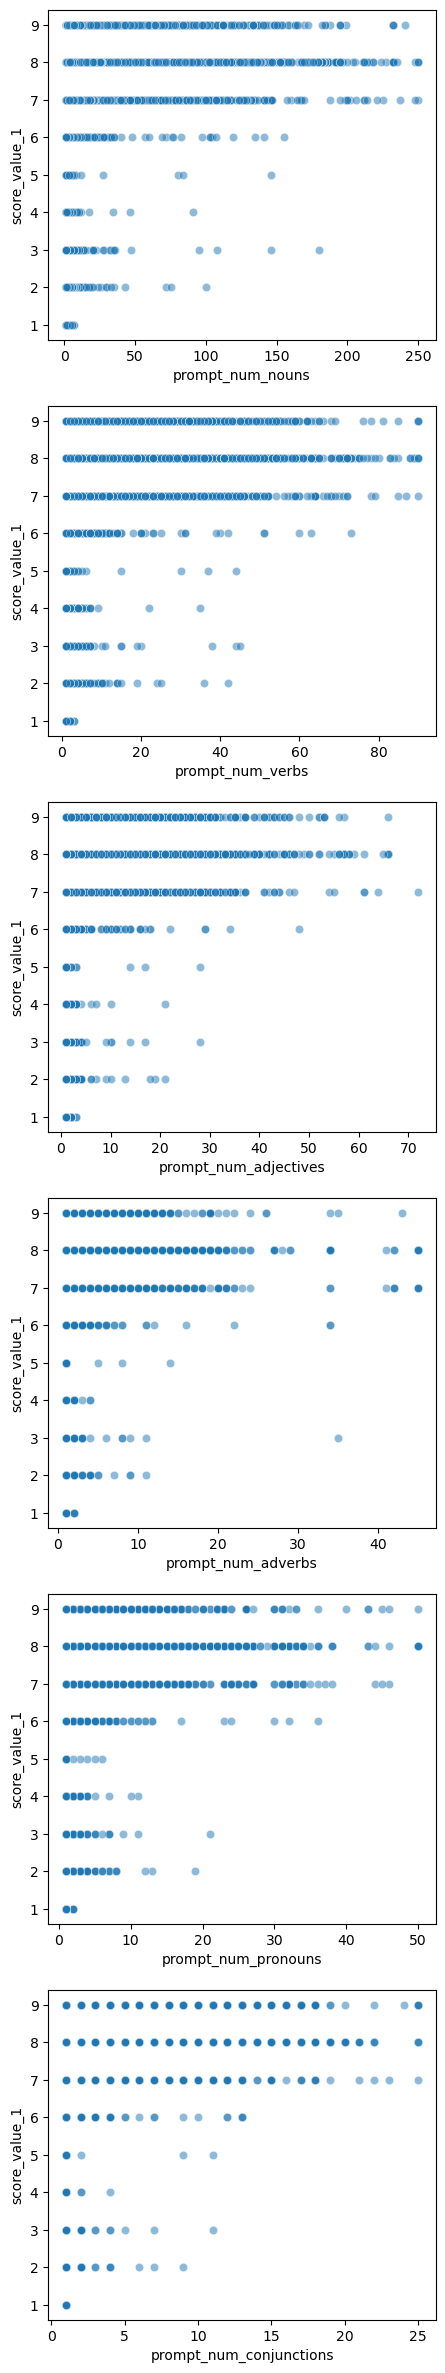

In [17]:
temp = ['prompt_num_nouns','prompt_num_verbs','prompt_num_adjectives','prompt_num_adverbs','prompt_num_pronouns','prompt_num_conjunctions']
fig, axes = plt.subplots(len(temp), 1, figsize=(5, 5*len(temp)))
for i in range(len(temp)):
    sns.scatterplot(data=dat, x=temp[i], y='score_value_1', alpha=0.5, ax=axes[i])

In [18]:
# create binary features for whether each of the keyword exist in the prompt question
# these keywords may provide additional information about the prompt question type and meaning

keywords = ['what','how','why','when','where','who','which','tell','explain','give','write','create','generate','describe','list','show','solve','count','make','if']
for kw in keywords:
    dat[kw] = dat['prompt'].str.contains(kw, case=False).astype(int)

dat.head()

,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner,prompt_word_count,prompt_word_count_log,prompt_char_count,prompt_char_count_log,prompt_punc_count,prompt_punc_count_log,prompt_num_nouns,prompt_num_verbs,prompt_num_adjectives,prompt_num_adverbs,prompt_num_pronouns,prompt_num_conjunctions,prompt_num_nouns_log,prompt_num_verbs_log,prompt_num_adjectives_log,prompt_num_adverbs_log,prompt_num_pronouns_log,prompt_num_conjunctions_log,what,how,why,when,where,who,which,tell,explain,give,write,create,generate,describe,list,show,solve,count,make,if
0,What is the difference between OpenCL and CUDA?,Technical Comparison,This prompt requires the AI to accurately comp...,9,Software Comparison,This prompt assesses the AI's factual accuracy...,8,"Comparison, Technology",This prompt requires the AI to demonstrate kno...,9,"Comparison, Time","Technology, Engineering","Comparison, Time",chatglm-6b,koala-13b,model_b,8,2.079442,47,3.850148,1,0.000000,3,1,1,1,1,1,1.098612,0.000000,0.0,0.0,0.000000,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,Why did my parent not invite me to their wedding?,"Reasoning, Emotion",This prompt requires the AI to understand huma...,9,"Emotions, Relationships",This prompt involves understanding complex hum...,8,"Reasoning, Emotional",This prompt challenges the AI to infer motives...,8,"Emotional, Psychology","Emotional, Psychology","Emotional, Psychology",oasst-pythia-12b,alpaca-13b,tie,10,2.302585,49,3.891820,1,0.000000,2,2,1,1,3,1,0.693147,0.693147,0.0,0.0,1.098612,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,"Fuji vs. Nikon, which is better?",Camera comparison,This prompt does not require problem-solving s...,2,Comparative Analysis,This prompt assesses the AI's ability to analy...,6,Photography comparison,This prompt is subjective and does not provide...,2,"Identification, Classification","Comparison, Time","Identification, Classification",koala-13b,oasst-pythia-12b,model_b,6,1.791759,32,3.465736,3,1.098612,3,1,1,1,1,1,1.098612,0.000000,0.0,0.0,0.000000,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,How to build an arena for chatbots?,Chatbot Arena,This prompt requires problem-solving skills an...,8,Chatbot Arena,This prompt requires the AI to engage in probl...,8,Chatbot Arena,This prompt requires problem-solving skills an...,8,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",vicuna-13b,oasst-pythia-12b,model_b,7,1.945910,35,3.555348,1,0.000000,2,1,1,1,1,1,0.693147,0.000000,0.0,0.0,0.000000,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,When is it today?,Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,"Comparison, Time","Comparison, Time","Comparison, Time",vicuna-13b,koala-13b,model_a,4,1.386294,17,2.833213,1,0.000000,1,1,1,1,1,1,0.000000,0.000000,0.0,0.0,0.000000,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


number of keywords extracted 20


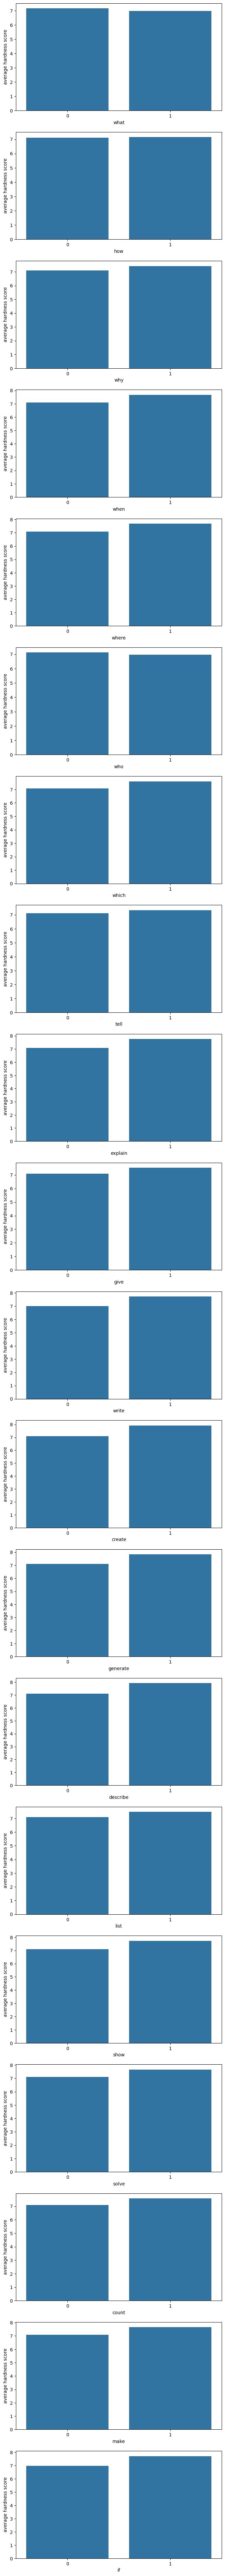

In [19]:
temp = len(keywords)
print('number of keywords extracted', temp)
fig, axes = plt.subplots(temp, 1, figsize=(8, 5*temp))
for i in range(temp):
    temp_dat = dat.groupby(keywords[i])['score_value_1'].mean()
    sns.barplot(x=temp_dat.index, y=temp_dat.values, ax=axes[i])
    axes[i].set_ylabel('average hardness score')

In [20]:
dat[keywords].sum(axis=0)

what        6818
how         4582
why         1066
when        1187
where        918
who         1757
which       1511
tell        1354
explain     1225
give        1901
write       3402
create       922
generate     628
describe     566
list        1296
show         498
solve        502
count        757
make        1289
if          4491
dtype: int64

In [21]:
# transform the winner column as 3 binary features

dat['winner'].replace(inplace=True, to_replace={'model_a':'one winner', 
                                                'model_b':'one winner', 
                                                'tie':'both good', 
                                                'tie (bothbad)':'both bad'})
dat.head()

,prompt,topic_modeling_1,score_reason_1,score_value_1,topic_modeling_2,score_reason_2,score_value_2,topic_modeling_3,score_reason_3,score_value_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,model_a,model_b,winner,prompt_word_count,prompt_word_count_log,prompt_char_count,prompt_char_count_log,prompt_punc_count,prompt_punc_count_log,prompt_num_nouns,prompt_num_verbs,prompt_num_adjectives,prompt_num_adverbs,prompt_num_pronouns,prompt_num_conjunctions,prompt_num_nouns_log,prompt_num_verbs_log,prompt_num_adjectives_log,prompt_num_adverbs_log,prompt_num_pronouns_log,prompt_num_conjunctions_log,what,how,why,when,where,who,which,tell,explain,give,write,create,generate,describe,list,show,solve,count,make,if
0,What is the difference between OpenCL and CUDA?,Technical Comparison,This prompt requires the AI to accurately comp...,9,Software Comparison,This prompt assesses the AI's factual accuracy...,8,"Comparison, Technology",This prompt requires the AI to demonstrate kno...,9,"Comparison, Time","Technology, Engineering","Comparison, Time",chatglm-6b,koala-13b,one winner,8,2.079442,47,3.850148,1,0.000000,3,1,1,1,1,1,1.098612,0.000000,0.0,0.0,0.000000,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,Why did my parent not invite me to their wedding?,"Reasoning, Emotion",This prompt requires the AI to understand huma...,9,"Emotions, Relationships",This prompt involves understanding complex hum...,8,"Reasoning, Emotional",This prompt challenges the AI to infer motives...,8,"Emotional, Psychology","Emotional, Psychology","Emotional, Psychology",oasst-pythia-12b,alpaca-13b,both good,10,2.302585,49,3.891820,1,0.000000,2,2,1,1,3,1,0.693147,0.693147,0.0,0.0,1.098612,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,"Fuji vs. Nikon, which is better?",Camera comparison,This prompt does not require problem-solving s...,2,Comparative Analysis,This prompt assesses the AI's ability to analy...,6,Photography comparison,This prompt is subjective and does not provide...,2,"Identification, Classification","Comparison, Time","Identification, Classification",koala-13b,oasst-pythia-12b,one winner,6,1.791759,32,3.465736,3,1.098612,3,1,1,1,1,1,1.098612,0.000000,0.0,0.0,0.000000,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,How to build an arena for chatbots?,Chatbot Arena,This prompt requires problem-solving skills an...,8,Chatbot Arena,This prompt requires the AI to engage in probl...,8,Chatbot Arena,This prompt requires problem-solving skills an...,8,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",vicuna-13b,oasst-pythia-12b,one winner,7,1.945910,35,3.555348,1,0.000000,2,1,1,1,1,1,0.693147,0.000000,0.0,0.0,0.000000,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,When is it today?,Time Query,This prompt is very straightforward and does n...,2,Date Inquiry,This prompt is very straightforward and does n...,2,Time-based Inquiry,This prompt is too straightforward and simply ...,2,"Comparison, Time","Comparison, Time","Comparison, Time",vicuna-13b,koala-13b,one winner,4,1.386294,17,2.833213,1,0.000000,1,1,1,1,1,1,0.000000,0.000000,0.0,0.0,0.000000,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [22]:
temp_dat = dat.groupby('winner')['score_value_1'].mean()
temp_dat

winner
both bad      7.249514
both good     6.747486
one winner    7.135011
Name: score_value_1, dtype: float64

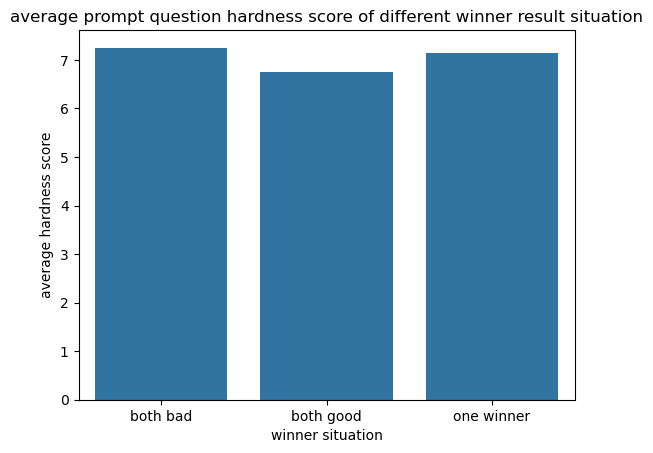

In [23]:
sns.barplot(x=temp_dat.index, y=temp_dat.values)
plt.xlabel('winner situation')
plt.ylabel('average hardness score')
plt.title('average prompt question hardness score of different winner result situation')
plt.show()

In [24]:
# one hot encode categorical features
enc = OneHotEncoder()
enc.fit(dat[['topic_modeling_1_cluster','winner']])
one_hot_encoded_df = pd.DataFrame(
    enc.transform(dat[['topic_modeling_1_cluster','winner']]).toarray(),
    columns = enc.get_feature_names_out()
)
print(one_hot_encoded_df.shape)
one_hot_encoded_df.head()

(25256, 33)


,"topic_modeling_1_cluster_AI, Task","topic_modeling_1_cluster_Communication, Chatbot","topic_modeling_1_cluster_Comparison, Time","topic_modeling_1_cluster_Counting, Sorting","topic_modeling_1_cluster_Creativity, Creative","topic_modeling_1_cluster_Data, Database","topic_modeling_1_cluster_Emotional, Psychology","topic_modeling_1_cluster_Ethics, Legal","topic_modeling_1_cluster_Evaluation, Analysis","topic_modeling_1_cluster_Factual, Philosophy","topic_modeling_1_cluster_Financial, Finance","topic_modeling_1_cluster_Food, Recipe","topic_modeling_1_cluster_Game, Gaming","topic_modeling_1_cluster_Geography, Astronomy","topic_modeling_1_cluster_History, Historical","topic_modeling_1_cluster_Identification, Classification","topic_modeling_1_cluster_Language, Text","topic_modeling_1_cluster_Logic, Reasoning","topic_modeling_1_cluster_Mathematics, Mathematical","topic_modeling_1_cluster_Medical, Biology","topic_modeling_1_cluster_Physics, Chemistry","topic_modeling_1_cluster_Poetry, Music","topic_modeling_1_cluster_Problem-solving, Optimization","topic_modeling_1_cluster_Programming, Development","topic_modeling_1_cluster_Programming, Python","topic_modeling_1_cluster_Recommendation, Travel","topic_modeling_1_cluster_Security, Cybersecurity","topic_modeling_1_cluster_Storytelling, Role-playing","topic_modeling_1_cluster_Summarization, Research","topic_modeling_1_cluster_Technology, Engineering",winner_both bad,winner_both good,winner_one winner
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [25]:
dat_merged = pd.merge(left=one_hot_encoded_df, 
                      right=dat[['prompt_word_count_log',
                                 'prompt_char_count_log',
                                 'prompt_punc_count_log',
                                 'prompt_num_nouns_log',
                                 'prompt_num_verbs_log',
                                 'prompt_num_adjectives_log',
                                 'prompt_num_adverbs_log',
                                 'prompt_num_pronouns_log',
                                 'prompt_num_conjunctions_log'] + keywords], 
                      how='inner', 
                      right_index=True, 
                      left_index=True)

print(dat_merged.shape)
dat_merged.head()

(25256, 62)


,"topic_modeling_1_cluster_AI, Task","topic_modeling_1_cluster_Communication, Chatbot","topic_modeling_1_cluster_Comparison, Time","topic_modeling_1_cluster_Counting, Sorting","topic_modeling_1_cluster_Creativity, Creative","topic_modeling_1_cluster_Data, Database","topic_modeling_1_cluster_Emotional, Psychology","topic_modeling_1_cluster_Ethics, Legal","topic_modeling_1_cluster_Evaluation, Analysis","topic_modeling_1_cluster_Factual, Philosophy","topic_modeling_1_cluster_Financial, Finance","topic_modeling_1_cluster_Food, Recipe","topic_modeling_1_cluster_Game, Gaming","topic_modeling_1_cluster_Geography, Astronomy","topic_modeling_1_cluster_History, Historical","topic_modeling_1_cluster_Identification, Classification","topic_modeling_1_cluster_Language, Text","topic_modeling_1_cluster_Logic, Reasoning","topic_modeling_1_cluster_Mathematics, Mathematical","topic_modeling_1_cluster_Medical, Biology","topic_modeling_1_cluster_Physics, Chemistry","topic_modeling_1_cluster_Poetry, Music","topic_modeling_1_cluster_Problem-solving, Optimization","topic_modeling_1_cluster_Programming, Development","topic_modeling_1_cluster_Programming, Python","topic_modeling_1_cluster_Recommendation, Travel","topic_modeling_1_cluster_Security, Cybersecurity","topic_modeling_1_cluster_Storytelling, Role-playing","topic_modeling_1_cluster_Summarization, Research","topic_modeling_1_cluster_Technology, Engineering",winner_both bad,winner_both good,winner_one winner,prompt_word_count_log,prompt_char_count_log,prompt_punc_count_log,prompt_num_nouns_log,prompt_num_verbs_log,prompt_num_adjectives_log,prompt_num_adverbs_log,prompt_num_pronouns_log,prompt_num_conjunctions_log,what,how,why,when,where,who,which,tell,explain,give,write,create,generate,describe,list,show,solve,count,make,if
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.079442,3.850148,0.000000,1.098612,0.000000,0.0,0.0,0.000000,0.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.302585,3.891820,0.000000,0.693147,0.693147,0.0,0.0,1.098612,0.0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.791759,3.465736,1.098612,1.098612,0.000000,0.0,0.0,0.000000,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.945910,3.555348,0.000000,0.693147,0.000000,0.0,0.0,0.000000,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.386294,2.833213,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## linear regression

In [26]:
def y_pred_transform(y_pred):
    
    return np.clip(np.round(y_pred,0), a_min=1, a_max=10)

In [27]:
def cross_validation(folds, X, y, model):

    kf = KFold(n_splits=folds, shuffle=True, random_state=200)
    train_mse = []
    val_mse = []
    for i, (train_index, val_index) in enumerate(kf.split(X)):

        print('iteration:',i)
        
        temp_X_train = X[train_index,:]
        temp_X_val = X[val_index,:]
        temp_y_train = y[train_index]
        temp_y_val = y[val_index]
        
        model.fit(temp_X_train, temp_y_train)
        
        temp_y_train_pred = y_pred_transform(model.predict(temp_X_train))
        temp_y_val_pred = y_pred_transform(model.predict(temp_X_val))
        train_mse.append(mean_squared_error(temp_y_train, temp_y_train_pred))
        val_mse.append(mean_squared_error(temp_y_val, temp_y_val_pred))

    return train_mse, val_mse

In [28]:
# full feature set

In [29]:
X = np.hstack((np.array(dat_merged), prompt_embeddings))
y = np.array(dat['score_value_1'])

# 30 + 3 + 20 + 3 + 6 + 256
print(X.shape)

(25256, 318)


In [30]:
reg_full_feat = LinearRegression(fit_intercept=True)
ridge_full_feat = Ridge(fit_intercept=True, alpha=1)
lasso_full_feat = Lasso(fit_intercept=True, alpha=1)

In [31]:
print('full feature set\n')

print('linear regression w/o regularization')
train_mse, val_mse = cross_validation(folds=5, X=X, y=y, model=reg_full_feat)
print('training mse:', np.mean(train_mse))
print(val_mse)
print('testing mse:', np.mean(val_mse))

print('\nridge regression')
train_mse, val_mse = cross_validation(folds=5, X=X, y=y, model=ridge_full_feat)
print('training mse:', np.mean(train_mse))
print(val_mse)
print('testing mse:', np.mean(val_mse))

print('\nlasso regression')
train_mse, val_mse = cross_validation(folds=5, X=X, y=y, model=lasso_full_feat)
print('training mse:', np.mean(train_mse))
print(val_mse)
print('testing mse:', np.mean(val_mse))

full feature set

linear regression w/o regularization
iteration: 0
iteration: 1
iteration: 2
iteration: 3
iteration: 4
training mse: 2.399717053831174
[2.4182501979414095, 2.598297366858048, 2.367056028509206, 2.4034844585230646, 2.539695109879232]
testing mse: 2.465356632342192

ridge regression
iteration: 0
iteration: 1
iteration: 2
iteration: 3
iteration: 4
training mse: 2.3998061402009325
[2.4144893111638956, 2.5980993862601465, 2.367056028509206, 2.396753118194417, 2.5365274203128094]
testing mse: 2.462585052888095

lasso regression
iteration: 0
iteration: 1
iteration: 2
iteration: 3
iteration: 4
training mse: 3.664357231075987
[3.5647268408551067, 3.8030093050881013, 3.4864383290437537, 3.6869926747178776, 3.7806374975252424]
testing mse: 3.6643609294460164


In [32]:
# feature set without cluster features

In [33]:
X = np.hstack((dat_merged[[col for col in dat_merged.columns if not col.startswith('topic')]], 
               prompt_embeddings))
y = np.array(dat['score_value_1'])

# 3 + 20 + 3 + 6 + 256
print(X.shape)

(25256, 288)


In [34]:
reg_wo_cluster_feat = LinearRegression(fit_intercept=True)
ridge_wo_cluster_feat = Ridge(fit_intercept=True, alpha=1)
lasso_wo_cluster_feat = Lasso(fit_intercept=True, alpha=1)

In [35]:
print('feature set w/o cluster features\n')

print('linear regression w/o regularization')
train_mse, val_mse = cross_validation(folds=5, X=X, y=y, model=reg_full_feat)
print('training mse:', np.mean(train_mse))
print('testing mse:', np.mean(val_mse))

print('\nridge regression')
train_mse, val_mse = cross_validation(folds=5, X=X, y=y, model=ridge_full_feat)
print('training mse:', np.mean(train_mse))
print('testing mse:', np.mean(val_mse))

print('\nlasso regression')
train_mse, val_mse = cross_validation(folds=5, X=X, y=y, model=lasso_full_feat)
print('training mse:', np.mean(train_mse))
print('testing mse:', np.mean(val_mse))

feature set w/o cluster features

linear regression w/o regularization
iteration: 0
iteration: 1
iteration: 2
iteration: 3
iteration: 4
training mse: 2.498842054547697
testing mse: 2.567075262253753

ridge regression
iteration: 0
iteration: 1
iteration: 2
iteration: 3
iteration: 4
training mse: 2.500524753429398
testing mse: 2.570163626339916

lasso regression
iteration: 0
iteration: 1
iteration: 2
iteration: 3
iteration: 4
training mse: 3.664357231075987
testing mse: 3.6643609294460164


In [36]:
# final model with full feature set using all training data

In [37]:
X = np.hstack((np.array(dat_merged), prompt_embeddings))
y = np.array(dat['score_value_1'])

# 30 + 3 + 20 + 3 + 6 + 256
print(X.shape)

(25256, 318)


In [38]:
ridge_full_feat = Ridge(fit_intercept=True, alpha=1)
ridge_full_feat.fit(X, y)

y_pred = y_pred_transform(ridge_full_feat.predict(X))
print('training mse:', mean_squared_error(y, y_pred))

training mse: 2.4006968641114983


## test data

In [39]:
prompt_embeddings_test = np.load(
    "/home/jovyan/_shared/data100-readonly/fa24_grad_project_data/nlp-chatbot-analysis_data/test-set/arena-test-set-prompts-embeddings.npy"
)

print(prompt_embeddings_test.shape)

(3200, 256)


In [40]:
hayden_cluster_test = pd.read_csv('hayden_cluster_test_deciphered.csv')

print(hayden_cluster_test.shape)
hayden_cluster_test.head()

(3200, 8)


,question_id,prompt,topic_modeling_1,topic_modeling_2,topic_modeling_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster
0,4f332ebd8cdc4ff2be74aa8828ff20d5,what do you think about the future of iran?,Future Prediction,Future Prediction,Future Prediction,"Comparison, Time","Comparison, Time","Comparison, Time"
1,f2be6f13e5ed40e5b81443223996494c,Salut ! Tu es un méchant chatbot !,"Role-playing, Evaluation","Role-play, Evaluation","Creativity, Factual Accuracy","Storytelling, Role-playing","Storytelling, Role-playing","Factual, Philosophy"
2,5fafefb8a0c54243afb52d2892946cea,⚔️ Chatbot Arena ⚔️\nRules:\n Chat with two...,Chatbot Evaluation,Chatbot Evaluation,Chatbot Evaluation,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot"
3,7834f572267f40709ecebb273a2b346b,Guess the word that i have in my mind,Guessing Game,Word Guessing,Word Guessing,"Counting, Sorting","Counting, Sorting","Counting, Sorting"
4,1ccc7e58290245c4bd5457fce45f8640,You are a peasant living in the village. But s...,"Problem-Solving, Creativity",Problem Solving,"Problem-solving, Creativity","Creativity, Creative","Problem-solving, Optimization","Creativity, Creative"


In [41]:
hayden_cluster_test['prompt_word_count'] = hayden_cluster_test['prompt'].str.split().str.len()
hayden_cluster_test['prompt_word_count_log'] = np.log(hayden_cluster_test['prompt_word_count'])

hayden_cluster_test['prompt_char_count'] = hayden_cluster_test['prompt'].str.len()
hayden_cluster_test['prompt_char_count_log'] = np.log(hayden_cluster_test['prompt_char_count'])

hayden_cluster_test['prompt_punc_count'] = hayden_cluster_test['prompt'].apply(count_punctuation)
hayden_cluster_test.loc[(hayden_cluster_test['prompt_punc_count']==0), 'prompt_punc_count'] = 1
hayden_cluster_test['prompt_punc_count_log'] = np.log(hayden_cluster_test['prompt_punc_count'])

hayden_cluster_test.head()

,question_id,prompt,topic_modeling_1,topic_modeling_2,topic_modeling_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,prompt_word_count,prompt_word_count_log,prompt_char_count,prompt_char_count_log,prompt_punc_count,prompt_punc_count_log
0,4f332ebd8cdc4ff2be74aa8828ff20d5,what do you think about the future of iran?,Future Prediction,Future Prediction,Future Prediction,"Comparison, Time","Comparison, Time","Comparison, Time",9,2.197225,43,3.761200,1,0.000000
1,f2be6f13e5ed40e5b81443223996494c,Salut ! Tu es un méchant chatbot !,"Role-playing, Evaluation","Role-play, Evaluation","Creativity, Factual Accuracy","Storytelling, Role-playing","Storytelling, Role-playing","Factual, Philosophy",8,2.079442,34,3.526361,1,0.000000
2,5fafefb8a0c54243afb52d2892946cea,⚔️ Chatbot Arena ⚔️\nRules:\n Chat with two...,Chatbot Evaluation,Chatbot Evaluation,Chatbot Evaluation,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",57,4.043051,325,5.783825,3,1.098612
3,7834f572267f40709ecebb273a2b346b,Guess the word that i have in my mind,Guessing Game,Word Guessing,Word Guessing,"Counting, Sorting","Counting, Sorting","Counting, Sorting",9,2.197225,37,3.610918,1,0.000000
4,1ccc7e58290245c4bd5457fce45f8640,You are a peasant living in the village. But s...,"Problem-Solving, Creativity",Problem Solving,"Problem-solving, Creativity","Creativity, Creative","Problem-solving, Optimization","Creativity, Creative",33,3.496508,166,5.111988,5,1.609438


In [42]:
temp_dat = hayden_cluster_test['prompt'].apply(lambda x: pd.Series(extract_pos_features(x)))

temp_dat['prompt_num_nouns_log'] = np.log(temp_dat['prompt_num_nouns'])
temp_dat['prompt_num_verbs_log'] = np.log(temp_dat['prompt_num_verbs'])
temp_dat['prompt_num_adjectives_log'] = np.log(temp_dat['prompt_num_adjectives'])
temp_dat['prompt_num_adverbs_log'] = np.log(temp_dat['prompt_num_adverbs'])
temp_dat['prompt_num_pronouns_log'] = np.log(temp_dat['prompt_num_pronouns'])
temp_dat['prompt_num_conjunctions_log'] = np.log(temp_dat['prompt_num_conjunctions'])

In [43]:
hayden_cluster_test = hayden_cluster_test.merge(right=temp_dat, how='inner', left_index=True, right_index=True)
hayden_cluster_test.head()

,question_id,prompt,topic_modeling_1,topic_modeling_2,topic_modeling_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,prompt_word_count,prompt_word_count_log,prompt_char_count,prompt_char_count_log,prompt_punc_count,prompt_punc_count_log,prompt_num_nouns,prompt_num_verbs,prompt_num_adjectives,prompt_num_adverbs,prompt_num_pronouns,prompt_num_conjunctions,prompt_num_nouns_log,prompt_num_verbs_log,prompt_num_adjectives_log,prompt_num_adverbs_log,prompt_num_pronouns_log,prompt_num_conjunctions_log
0,4f332ebd8cdc4ff2be74aa8828ff20d5,what do you think about the future of iran?,Future Prediction,Future Prediction,Future Prediction,"Comparison, Time","Comparison, Time","Comparison, Time",9,2.197225,43,3.761200,1,0.000000,2,2,1,1,1,1,0.693147,0.693147,0.000000,0.0,0.000000,0.000000
1,f2be6f13e5ed40e5b81443223996494c,Salut ! Tu es un méchant chatbot !,"Role-playing, Evaluation","Role-play, Evaluation","Creativity, Factual Accuracy","Storytelling, Role-playing","Storytelling, Role-playing","Factual, Philosophy",8,2.079442,34,3.526361,1,0.000000,4,1,2,1,1,1,1.386294,0.000000,0.693147,0.0,0.000000,0.000000
2,5fafefb8a0c54243afb52d2892946cea,⚔️ Chatbot Arena ⚔️\nRules:\n Chat with two...,Chatbot Evaluation,Chatbot Evaluation,Chatbot Evaluation,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",57,4.043051,325,5.783825,3,1.098612,18,8,5,1,3,4,2.890372,2.079442,1.609438,0.0,1.098612,1.386294
3,7834f572267f40709ecebb273a2b346b,Guess the word that i have in my mind,Guessing Game,Word Guessing,Word Guessing,"Counting, Sorting","Counting, Sorting","Counting, Sorting",9,2.197225,37,3.610918,1,0.000000,3,2,1,1,1,1,1.098612,0.693147,0.000000,0.0,0.000000,0.000000
4,1ccc7e58290245c4bd5457fce45f8640,You are a peasant living in the village. But s...,"Problem-Solving, Creativity",Problem Solving,"Problem-solving, Creativity","Creativity, Creative","Problem-solving, Optimization","Creativity, Creative",33,3.496508,166,5.111988,5,1.609438,6,8,2,1,5,2,1.791759,2.079442,0.693147,0.0,1.609438,0.693147


In [44]:
keywords = ['what','how','why','when','where','who','which','tell','explain','give','write','create','generate','describe','list','show','solve','count','make','if']
for kw in keywords:
    hayden_cluster_test[kw] = hayden_cluster_test['prompt'].str.contains(kw, case=False).astype(int)

hayden_cluster_test.head()

,question_id,prompt,topic_modeling_1,topic_modeling_2,topic_modeling_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,prompt_word_count,prompt_word_count_log,prompt_char_count,prompt_char_count_log,prompt_punc_count,prompt_punc_count_log,prompt_num_nouns,prompt_num_verbs,prompt_num_adjectives,prompt_num_adverbs,prompt_num_pronouns,prompt_num_conjunctions,prompt_num_nouns_log,prompt_num_verbs_log,prompt_num_adjectives_log,prompt_num_adverbs_log,prompt_num_pronouns_log,prompt_num_conjunctions_log,what,how,why,when,where,who,which,tell,explain,give,write,create,generate,describe,list,show,solve,count,make,if
0,4f332ebd8cdc4ff2be74aa8828ff20d5,what do you think about the future of iran?,Future Prediction,Future Prediction,Future Prediction,"Comparison, Time","Comparison, Time","Comparison, Time",9,2.197225,43,3.761200,1,0.000000,2,2,1,1,1,1,0.693147,0.693147,0.000000,0.0,0.000000,0.000000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,f2be6f13e5ed40e5b81443223996494c,Salut ! Tu es un méchant chatbot !,"Role-playing, Evaluation","Role-play, Evaluation","Creativity, Factual Accuracy","Storytelling, Role-playing","Storytelling, Role-playing","Factual, Philosophy",8,2.079442,34,3.526361,1,0.000000,4,1,2,1,1,1,1.386294,0.000000,0.693147,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,5fafefb8a0c54243afb52d2892946cea,⚔️ Chatbot Arena ⚔️\nRules:\n Chat with two...,Chatbot Evaluation,Chatbot Evaluation,Chatbot Evaluation,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",57,4.043051,325,5.783825,3,1.098612,18,8,5,1,3,4,2.890372,2.079442,1.609438,0.0,1.098612,1.386294,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,7834f572267f40709ecebb273a2b346b,Guess the word that i have in my mind,Guessing Game,Word Guessing,Word Guessing,"Counting, Sorting","Counting, Sorting","Counting, Sorting",9,2.197225,37,3.610918,1,0.000000,3,2,1,1,1,1,1.098612,0.693147,0.000000,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1ccc7e58290245c4bd5457fce45f8640,You are a peasant living in the village. But s...,"Problem-Solving, Creativity",Problem Solving,"Problem-solving, Creativity","Creativity, Creative","Problem-solving, Optimization","Creativity, Creative",33,3.496508,166,5.111988,5,1.609438,6,8,2,1,5,2,1.791759,2.079442,0.693147,0.0,1.609438,0.693147,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [45]:
submit_df = pd.read_csv('taskA_results.csv')

hayden_cluster_test = hayden_cluster_test.merge(submit_df[['winner']], how='inner', left_index=True, right_index=True)
hayden_cluster_test['winner'].replace(inplace=True, to_replace={'model_a':'one winner', 
                                                                'model_b':'one winner', 
                                                                'tie':'both good', 
                                                                'tie (bothbad)':'both bad'})

hayden_cluster_test.head()

,question_id,prompt,topic_modeling_1,topic_modeling_2,topic_modeling_3,topic_modeling_1_cluster,topic_modeling_2_cluster,topic_modeling_3_cluster,prompt_word_count,prompt_word_count_log,prompt_char_count,prompt_char_count_log,prompt_punc_count,prompt_punc_count_log,prompt_num_nouns,prompt_num_verbs,prompt_num_adjectives,prompt_num_adverbs,prompt_num_pronouns,prompt_num_conjunctions,prompt_num_nouns_log,prompt_num_verbs_log,prompt_num_adjectives_log,prompt_num_adverbs_log,prompt_num_pronouns_log,prompt_num_conjunctions_log,what,how,why,when,where,who,which,tell,explain,give,write,create,generate,describe,list,show,solve,count,make,if,winner
0,4f332ebd8cdc4ff2be74aa8828ff20d5,what do you think about the future of iran?,Future Prediction,Future Prediction,Future Prediction,"Comparison, Time","Comparison, Time","Comparison, Time",9,2.197225,43,3.761200,1,0.000000,2,2,1,1,1,1,0.693147,0.693147,0.000000,0.0,0.000000,0.000000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,one winner
1,f2be6f13e5ed40e5b81443223996494c,Salut ! Tu es un méchant chatbot !,"Role-playing, Evaluation","Role-play, Evaluation","Creativity, Factual Accuracy","Storytelling, Role-playing","Storytelling, Role-playing","Factual, Philosophy",8,2.079442,34,3.526361,1,0.000000,4,1,2,1,1,1,1.386294,0.000000,0.693147,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,one winner
2,5fafefb8a0c54243afb52d2892946cea,⚔️ Chatbot Arena ⚔️\nRules:\n Chat with two...,Chatbot Evaluation,Chatbot Evaluation,Chatbot Evaluation,"Communication, Chatbot","Communication, Chatbot","Communication, Chatbot",57,4.043051,325,5.783825,3,1.098612,18,8,5,1,3,4,2.890372,2.079442,1.609438,0.0,1.098612,1.386294,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,one winner
3,7834f572267f40709ecebb273a2b346b,Guess the word that i have in my mind,Guessing Game,Word Guessing,Word Guessing,"Counting, Sorting","Counting, Sorting","Counting, Sorting",9,2.197225,37,3.610918,1,0.000000,3,2,1,1,1,1,1.098612,0.693147,0.000000,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,both bad
4,1ccc7e58290245c4bd5457fce45f8640,You are a peasant living in the village. But s...,"Problem-Solving, Creativity",Problem Solving,"Problem-solving, Creativity","Creativity, Creative","Problem-solving, Optimization","Creativity, Creative",33,3.496508,166,5.111988,5,1.609438,6,8,2,1,5,2,1.791759,2.079442,0.693147,0.0,1.609438,0.693147,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,one winner


In [46]:
one_hot_encoded_test_df = pd.DataFrame(
    enc.transform(hayden_cluster_test[['topic_modeling_1_cluster','winner']]).toarray(),
    columns = enc.get_feature_names_out()
)
print(one_hot_encoded_test_df.shape)
one_hot_encoded_test_df.head()

(3200, 33)


,"topic_modeling_1_cluster_AI, Task","topic_modeling_1_cluster_Communication, Chatbot","topic_modeling_1_cluster_Comparison, Time","topic_modeling_1_cluster_Counting, Sorting","topic_modeling_1_cluster_Creativity, Creative","topic_modeling_1_cluster_Data, Database","topic_modeling_1_cluster_Emotional, Psychology","topic_modeling_1_cluster_Ethics, Legal","topic_modeling_1_cluster_Evaluation, Analysis","topic_modeling_1_cluster_Factual, Philosophy","topic_modeling_1_cluster_Financial, Finance","topic_modeling_1_cluster_Food, Recipe","topic_modeling_1_cluster_Game, Gaming","topic_modeling_1_cluster_Geography, Astronomy","topic_modeling_1_cluster_History, Historical","topic_modeling_1_cluster_Identification, Classification","topic_modeling_1_cluster_Language, Text","topic_modeling_1_cluster_Logic, Reasoning","topic_modeling_1_cluster_Mathematics, Mathematical","topic_modeling_1_cluster_Medical, Biology","topic_modeling_1_cluster_Physics, Chemistry","topic_modeling_1_cluster_Poetry, Music","topic_modeling_1_cluster_Problem-solving, Optimization","topic_modeling_1_cluster_Programming, Development","topic_modeling_1_cluster_Programming, Python","topic_modeling_1_cluster_Recommendation, Travel","topic_modeling_1_cluster_Security, Cybersecurity","topic_modeling_1_cluster_Storytelling, Role-playing","topic_modeling_1_cluster_Summarization, Research","topic_modeling_1_cluster_Technology, Engineering",winner_both bad,winner_both good,winner_one winner
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [47]:
test_merged = pd.merge(left=one_hot_encoded_test_df, 
                       right=hayden_cluster_test[['prompt_word_count_log',
                                                  'prompt_char_count_log',
                                                  'prompt_punc_count_log',
                                                  'prompt_num_nouns_log',
                                                  'prompt_num_verbs_log',
                                                  'prompt_num_adjectives_log',
                                                  'prompt_num_adverbs_log',
                                                  'prompt_num_pronouns_log',
                                                  'prompt_num_conjunctions_log'] + keywords], 
                       how='inner', 
                       right_index=True, 
                       left_index=True)

print(test_merged.shape)
test_merged.head()

(3200, 62)


,"topic_modeling_1_cluster_AI, Task","topic_modeling_1_cluster_Communication, Chatbot","topic_modeling_1_cluster_Comparison, Time","topic_modeling_1_cluster_Counting, Sorting","topic_modeling_1_cluster_Creativity, Creative","topic_modeling_1_cluster_Data, Database","topic_modeling_1_cluster_Emotional, Psychology","topic_modeling_1_cluster_Ethics, Legal","topic_modeling_1_cluster_Evaluation, Analysis","topic_modeling_1_cluster_Factual, Philosophy","topic_modeling_1_cluster_Financial, Finance","topic_modeling_1_cluster_Food, Recipe","topic_modeling_1_cluster_Game, Gaming","topic_modeling_1_cluster_Geography, Astronomy","topic_modeling_1_cluster_History, Historical","topic_modeling_1_cluster_Identification, Classification","topic_modeling_1_cluster_Language, Text","topic_modeling_1_cluster_Logic, Reasoning","topic_modeling_1_cluster_Mathematics, Mathematical","topic_modeling_1_cluster_Medical, Biology","topic_modeling_1_cluster_Physics, Chemistry","topic_modeling_1_cluster_Poetry, Music","topic_modeling_1_cluster_Problem-solving, Optimization","topic_modeling_1_cluster_Programming, Development","topic_modeling_1_cluster_Programming, Python","topic_modeling_1_cluster_Recommendation, Travel","topic_modeling_1_cluster_Security, Cybersecurity","topic_modeling_1_cluster_Storytelling, Role-playing","topic_modeling_1_cluster_Summarization, Research","topic_modeling_1_cluster_Technology, Engineering",winner_both bad,winner_both good,winner_one winner,prompt_word_count_log,prompt_char_count_log,prompt_punc_count_log,prompt_num_nouns_log,prompt_num_verbs_log,prompt_num_adjectives_log,prompt_num_adverbs_log,prompt_num_pronouns_log,prompt_num_conjunctions_log,what,how,why,when,where,who,which,tell,explain,give,write,create,generate,describe,list,show,solve,count,make,if
0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.197225,3.761200,0.000000,0.693147,0.693147,0.000000,0.0,0.000000,0.000000,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,2.079442,3.526361,0.000000,1.386294,0.000000,0.693147,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.043051,5.783825,1.098612,2.890372,2.079442,1.609438,0.0,1.098612,1.386294,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.197225,3.610918,0.000000,1.098612,0.693147,0.000000,0.0,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.496508,5.111988,1.609438,1.791759,2.079442,0.693147,0.0,1.609438,0.693147,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [48]:
X_test = np.hstack((np.array(test_merged), prompt_embeddings_test))

# 30 + 3 + 20 + 3 + 6 + 256
print(X_test.shape)

(3200, 318)


In [49]:
# task B test data pred
y_pred = y_pred_transform(ridge_full_feat.predict(X_test))

In [50]:
unique_values, counts = np.unique(y_pred, return_counts=True)
print(unique_values)
print(counts)

[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
[ 95 132  87 104 273 608 936 717 232  16]


In [51]:
y = dat['score_value_1']
unique_values, counts = np.unique(y, return_counts=True)
print(unique_values)
print(counts)

[1 2 3 4 5 6 7 8 9]
[   95  2159   512   177    24   828  7161 10919  3381]


In [52]:
submit_df = hayden_cluster_test[['question_id']]
submit_df['hardness_score'] = y_pred

submit_df.head()

,question_id,hardness_score
0,4f332ebd8cdc4ff2be74aa8828ff20d5,6.0
1,f2be6f13e5ed40e5b81443223996494c,5.0
2,5fafefb8a0c54243afb52d2892946cea,7.0
3,7834f572267f40709ecebb273a2b346b,5.0
4,1ccc7e58290245c4bd5457fce45f8640,8.0


In [53]:
submit_df.to_csv('taskB_results.csv', index=False)

In [54]:
taskA_res = pd.read_csv('taskA_results.csv')
taskB_res = pd.read_csv('taskB_results.csv')

submit_df = pd.merge(left=taskA_res, right=taskB_res[['hardness_score']], how='inner', left_index=True, right_index=True)

print(submit_df.shape)
submit_df.head()

(3200, 3)


,question_id,winner,hardness_score
0,4f332ebd8cdc4ff2be74aa8828ff20d5,model_b,6.0
1,f2be6f13e5ed40e5b81443223996494c,model_b,5.0
2,5fafefb8a0c54243afb52d2892946cea,model_b,7.0
3,7834f572267f40709ecebb273a2b346b,tie (bothbad),5.0
4,1ccc7e58290245c4bd5457fce45f8640,model_a,8.0


In [55]:
submit_df.to_csv('ready_to_submit_tasks_AB.csv', index=False)